In [1]:
import sys
from pyprojroot import here

# Ritorna il percorso assoluto della root del progetto
PROJECT_ROOT = str(here()) + "/"
sys.path.append(PROJECT_ROOT)
sys.dont_write_bytecode = True

print(f"La root del progetto è: {PROJECT_ROOT}")

La root del progetto è: /home/cvalentino/SissaUnisaDraftCodes/


In [2]:
from paths import DRT_PATH, TP4_PATH

ABS_PATH = PROJECT_ROOT + DRT_PATH + TP4_PATH

model_name = "1_Base_Roccia"
xdmf_file_name = ABS_PATH + "1_Base_Roccia.xdmf"

load_fem_solution = ABS_PATH + "old_visualization/2_Base_FEM_Solution"
fem_h5 = load_fem_solution + ".h5"

load_pinn_solution = ABS_PATH + "old_visualization/3_Base_PINN_solution"
pinn_h5 = load_pinn_solution + ".h5"

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from analyze_xdmf import AnalyzeXdmf
from modelaquisition.msh2xdmf import Msh2Xdmf

In [4]:
an_fem = AnalyzeXdmf(fem_h5)
an_pinn = AnalyzeXdmf(pinn_h5)

In [5]:
an_fem.export_solution("./files/fem_solution.csv")
an_pinn.export_solution("./files/pinn_solution.csv")

In [6]:
err_a = np.abs(an_fem.solution - an_pinn.solution, dtype=np.float64)
err_r = err_a / np.linalg.norm(an_fem.solution)

df_a = pd.DataFrame(err_a)
df_a.to_csv("./files/absolute_error.csv", sep=";", index=None)
df_r = pd.DataFrame(err_r)
df_r.to_csv("./files/relative_error.csv", sep=";", index=None)

In [7]:
print(f"Errore assoluto: {np.linalg.norm(err_a):.4e}")
print(f"Errore relativo: {np.linalg.norm(err_a) / np.linalg.norm(an_fem.solution):.4e}")

Errore assoluto: 2.3241e+02
Errore relativo: 8.6973e-03


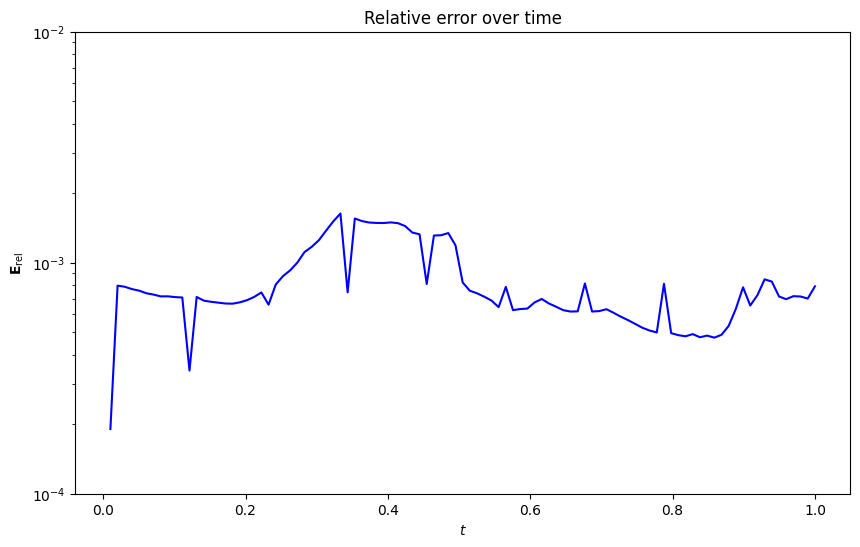

In [8]:
t = np.linspace(0, 1, err_r.shape[0])
err_time = np.linalg.norm(err_r, axis=1)

fig= plt.figure(figsize=(10, 6))

plt.plot(t[1:], err_time[1:], c="blue")
plt.xlabel("$t$")
plt.ylabel("$\mathbf{E}_\mathrm{rel}$")
plt.title("Relative error over time")
plt.yscale("log")
plt.ylim([1e-4, 1e-2])
plt.savefig("./figures/rel_err.png", transparent=True)
plt.show()

In [9]:
rock = Msh2Xdmf(xdmf_file_name, model_name)

In [10]:
rock.reset_files("_sol_pinn")
rock.reset_files("_sol_fem")

rock.add_solution(an_pinn.solution, "_sol_pinn", "solution_pinn", steps=t.shape[0])
rock.add_solution(an_fem.solution, "_sol_fem", "solution_fem", steps=t.shape[0])

File 1_Base_Roccia_sol_pinn.xdmf cancellato.
File 1_Base_Roccia_sol_pinn.h5 cancellato.
File 1_Base_Roccia_sol_fem.xdmf cancellato.
File 1_Base_Roccia_sol_fem.h5 cancellato.
Aggiunta soluzione temporale


Aggiunta soluzione temporale


In [11]:
rock.reset_files("_err")
rock.reset_files("_err_rel")
rock.add_solution(err_a, "_err", "error", steps=t.shape[0])
rock.add_solution(err_r, "_err_rel", "error_rel", steps=t.shape[0])

File 1_Base_Roccia_err.xdmf non trovato.
File 1_Base_Roccia_err.h5 non trovato.
File 1_Base_Roccia_err_rel.xdmf non trovato.
File 1_Base_Roccia_err_rel.h5 non trovato.
Aggiunta soluzione temporale
Aggiunta soluzione temporale
